# Moneli — Préparation des scénarios 2026

Ce notebook génère les données d'entrée pour la prédiction 2026.  
Il ne dépend pas du modèle d'Arthur — on peut le faire tourner maintenant.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Ajouter le dossier du projet au path pour importer config
sys.path.insert(0, os.path.dirname(os.getcwd()))
import config

print(' config.py chargé')
print('Dossier projet :', config.BASE_DIR)

 config.py chargé
Dossier projet : /Users/moneli/Documents/ProjetImmo


## 1. Charger les données réelles (2024 + 2025)

In [2]:
df24 = pd.read_csv(config.CSV_2024)
df25 = pd.read_csv(config.CSV_2025)

# Fusion
df = pd.concat([df24, df25], ignore_index=True)

# Garder uniquement Maison et Appartement
df = df[df[config.COL_TYPE].isin(config.TYPES_BIENS)].copy()

# Supprimer les lignes sans prix ou sans surface
df = df.dropna(subset=[config.COL_PRIX, config.COL_SURFACE])

# Ajouter colonnes année / mois
df['date_mutation'] = pd.to_datetime(df[config.COL_DATE])
df['annee']         = df['date_mutation'].dt.year
df['mois']          = df['date_mutation'].dt.month

# Calculer prix au m²
df['prix_m2'] = df[config.COL_PRIX] / df[config.COL_SURFACE]

# Supprimer valeurs aberrantes (prix/m² < 200 ou > 15000)
df = df[(df['prix_m2'] > 200) & (df['prix_m2'] < 15000)]

print(f' {len(df)} transactions après nettoyage')
print(df[config.COL_TYPE].value_counts())

 11521 transactions après nettoyage
type_local
Maison         8536
Appartement    2985
Name: count, dtype: int64


## 2. Statistiques réelles par type de bien

In [3]:
stats = df.groupby([config.COL_TYPE, 'annee']).agg(
    prix_moyen    = (config.COL_PRIX,    'mean'),
    prix_m2_moyen = ('prix_m2',          'mean'),
    surface_moy   = (config.COL_SURFACE, 'mean'),
    nb_ventes     = (config.COL_PRIX,    'count')
).round(0).reset_index()

print(stats.to_string(index=False))

 type_local  annee  prix_moyen  prix_m2_moyen  surface_moy  nb_ventes
Appartement   2024    190892.0         3738.0         57.0       2985
     Maison   2024    224208.0         2201.0        105.0       8536


## 3. Générer les scénarios 2026

On génère des biens fictifs représentatifs (surfaces et pièces typiques du 49)  
pour couvrir un large spectre : petit / moyen / grand, maison et appartement.

In [4]:
# Coordonnées GPS centrées sur Angers (centre du dept 49)
LAT_ANGERS = 47.478419
LON_ANGERS = -0.563166

scenarios = []

types_config = {
    'Maison':      {'surfaces': [60, 97, 130, 180],  'pieces': [3, 4, 5, 6],  'terrain': [300, 500, 800, 1200]},
    'Appartement': {'surfaces': [30, 50, 70, 100],   'pieces': [1, 2, 3, 4],  'terrain': [0,   0,   0,   0]},
}

for type_bien, cfg in types_config.items():
    for i in range(len(cfg['surfaces'])):
        # Légère variation GPS pour simuler différentes zones
        lat = LAT_ANGERS + np.random.uniform(-0.5, 0.5)
        lon = LON_ANGERS + np.random.uniform(-0.5, 0.5)

        scenarios.append({
            config.COL_TYPE:    type_bien,
            config.COL_SURFACE: cfg['surfaces'][i],
            config.COL_PIECES:  cfg['pieces'][i],
            config.COL_TERRAIN: cfg['terrain'][i],
            config.COL_LAT:     round(lat, 6),
            config.COL_LON:     round(lon, 6),
            'annee':            config.ANNEE_PRED,
            'mois':             6,  # on prédit au milieu de l'année
        })

X_2026 = pd.DataFrame(scenarios)
print(f' {len(X_2026)} scénarios générés')
print(X_2026)

 8 scénarios générés
    type_local  surface_reelle_bati  nombre_pieces_principales  \
0       Maison                   60                          3   
1       Maison                   97                          4   
2       Maison                  130                          5   
3       Maison                  180                          6   
4  Appartement                   30                          1   
5  Appartement                   50                          2   
6  Appartement                   70                          3   
7  Appartement                  100                          4   

   surface_terrain   latitude  longitude  annee  mois  
0              300  47.315721  -0.306876   2026     6  
1              500  47.431739  -0.196086   2026     6  
2              800  47.829282  -0.590793   2026     6  
3             1200  47.270402  -0.133271   2026     6  
4                0  47.568345  -0.099423   2026     6  
5                0  47.076955  -0.243470   2026 

## 4. Export X_2026.csv

In [5]:
X_2026.to_csv(config.X_2026, index=False)
print(f'Fichier exporté : {config.X_2026}')

Fichier exporté : /Users/moneli/Documents/ProjetImmo/X_2026.csv


## 5. Visualisation : évolution réelle 2024 → 2025

*(On ajoutera 2026 une fois le modèle d'Arthur dispo)*

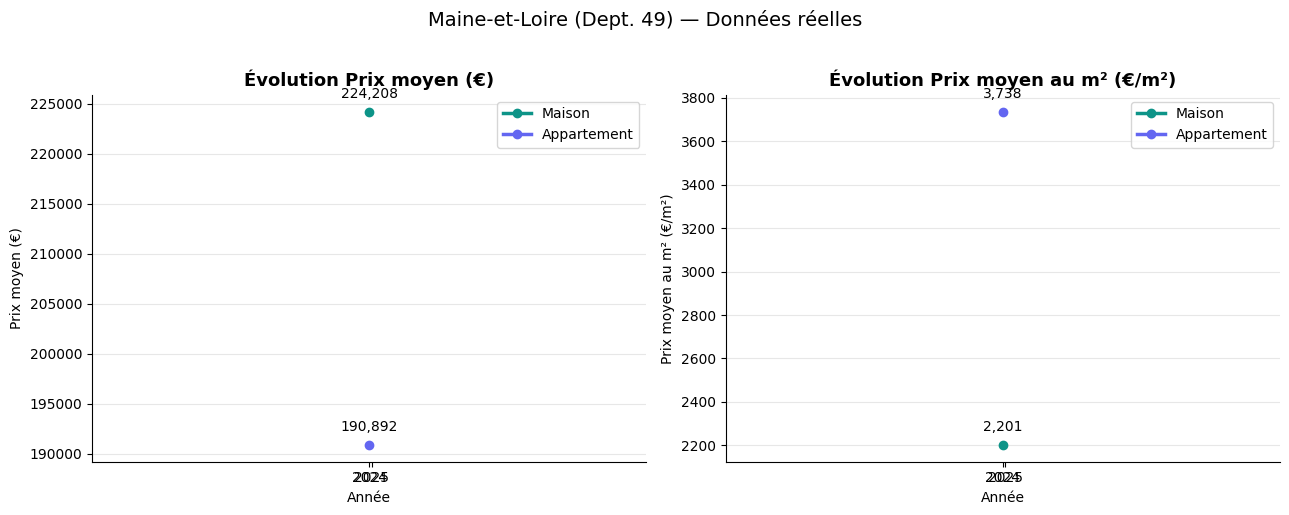

Graphique sauvegardé


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'Maison': '#0D9488', 'Appartement': '#6366F1'}

for ax, col, label in zip(
    axes,
    [config.COL_PRIX, 'prix_m2'],
    ['Prix moyen (€)', 'Prix moyen au m² (€/m²)']
):
    for type_bien in config.TYPES_BIENS:
        data = df[df[config.COL_TYPE] == type_bien].groupby('annee')[col].mean()
        ax.plot(data.index, data.values, marker='o', linewidth=2.5,
                label=type_bien, color=colors[type_bien])
        for x, y in zip(data.index, data.values):
            ax.annotate(f'{y:,.0f}', (x, y), textcoords='offset points',
                        xytext=(0, 10), ha='center', fontsize=10)

    ax.set_title(f'Évolution {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Année')
    ax.set_ylabel(label)
    ax.legend()
    ax.set_xticks([2024, 2025])
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Maine-et-Loire (Dept. 49) — Données réelles', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.BASE_DIR, 'evolution_2024_2025.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé')